# Customer Segmentation & Churn Prediction — Capstone Project

**Dataset:** Telco Customer Churn (7,043 customers, 21 features)

**Objective:** Segment customers using unsupervised learning (clustering) and predict customer churn
using supervised learning (classification), then combine both to generate actionable business insights.

---
### Notebook Sections
1. Setup & Imports
2. Data Loading
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Unsupervised Learning — Customer Segmentation
7. Supervised Learning — Churn Prediction
8. Model Evaluation
9. Integration — Segments + Churn Insights
10. Business Recommendations
11. Save Models & Outputs
---


## 1. Setup & Imports

In [7]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Unsupervised learning
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Supervised learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Saving models
import joblib

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Data Loading

We use the standard **Telco Customer Churn** dataset. The cell below downloads it automatically
so every team member gets the exact same file — no need to manually download from Kaggle.

### Option A — Download via Kaggle API (recommended for teams)

This uses Kaggle's official dataset directly instead of a mirror, and is fully automated —
every team member gets the exact same file with one command, no manual downloading.

**One-time setup (each team member does this once):**
1. Go to [kaggle.com](https://kaggle.com) → click your profile picture → **Account**
2. Scroll to **API** → click **Create New Token** → this downloads `kaggle.json`
3. Place it at:
   - Mac/Linux: `~/.kaggle/kaggle.json`
   - Windows: `C:\Users\<YourName>\.kaggle\kaggle.json`
4. Run `chmod 600 ~/.kaggle/kaggle.json` (Mac/Linux only, for security)

**Important:** Never commit `kaggle.json` to GitHub — it contains your personal API credentials.
It's already excluded via `.gitignore`.

```python
!pip install kaggle -q
```


In [8]:
import os
import subprocess

USE_KAGGLE_API = True  # set to False if you don't have kaggle.json set up yet

KAGGLE_DATA_DIR = "../data"
KAGGLE_ZIP = f"{KAGGLE_DATA_DIR}/telco-customer-churn.zip"

if USE_KAGGLE_API:
    try:
        os.makedirs(KAGGLE_DATA_DIR, exist_ok=True)
        subprocess.run(
            ["kaggle", "datasets", "download", "-d", "blastchar/telco-customer-churn",
             "-p", KAGGLE_DATA_DIR],
            check=True
        )
        import zipfile
        with zipfile.ZipFile(f"{KAGGLE_DATA_DIR}/telco-customer-churn.zip", 'r') as z:
            z.extractall(KAGGLE_DATA_DIR)
        print("Downloaded and extracted dataset from Kaggle API.")
    except Exception as e:
        print("Kaggle API download failed:", e)
        print("Falling back to Option B (GitHub mirror) or Option C (manual upload) below.")
        USE_KAGGLE_API = False


Kaggle API download failed: [WinError 2] The system cannot find the file specified
Falling back to Option B (GitHub mirror) or Option C (manual upload) below.


### Option B — GitHub mirror (no setup needed, automatic fallback)

If you don't want to set up Kaggle API credentials, this downloads the same dataset from a
public GitHub mirror automatically.

### Option C — Manual upload (if both A and B are unavailable, e.g. no internet on your machine)

1. Go to the [Telco Customer Churn dataset page](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) on Kaggle
2. Click **Download** (top right) — downloads a `.zip`
3. Extract it and rename the CSV to `telco_churn.csv`
4. Place it inside your project's `data/` folder: `project/data/telco_churn.csv`
5. Re-run the cell below — it will detect the local file and skip downloading entirely


In [9]:
import os
import glob

DATA_PATH = "../data/telco_churn.csv"
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

os.makedirs("../data", exist_ok=True)

# Check if Kaggle API (Option A) or manual upload (Option C) already produced a CSV
kaggle_csvs = glob.glob("../data/*.csv")
kaggle_csvs = [f for f in kaggle_csvs if "telco" in f.lower() or "churn" in f.lower()]

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print("Dataset loaded from:", DATA_PATH)
elif kaggle_csvs:
    # Found a CSV from Kaggle download - standardize its name
    source_file = kaggle_csvs[0]
    df = pd.read_csv(source_file)
    df.to_csv(DATA_PATH, index=False)
    print(f"Dataset loaded from Kaggle download ({source_file}) and standardized to {DATA_PATH}")
else:
    # Option B: fallback to GitHub mirror
    df = pd.read_csv(DATA_URL)
    df.to_csv(DATA_PATH, index=False)
    print("Dataset downloaded from GitHub mirror and saved to", DATA_PATH)

print("Shape:", df.shape)
df.head()


Dataset downloaded from GitHub mirror and saved to ../data/telco_churn.csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning

Known issues in this dataset:
- `TotalCharges` is stored as text and has blank strings for customers with 0 tenure (new customers) — needs conversion to numeric.
- `customerID` is a unique identifier and must be dropped before modeling (it's not a predictive feature).
- `SeniorCitizen` is encoded as 0/1 already; other categorical columns are strings.


In [12]:
# Check for missing / blank values
print("Blank TotalCharges count:", (df['TotalCharges'].str.strip() == '').sum())

# Convert TotalCharges to numeric; blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# These NaNs correspond to customers with tenure = 0 (brand new customers) -> fill with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirm no more missing values
print("\nMissing values after cleaning:")
print(df.isnull().sum().sum(), "total missing values")

# Drop the ID column (not predictive, keep a copy for reference)
customer_ids = df['customerID']
df_clean = df.drop(columns=['customerID'])

# Standardize Yes/No target
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print("\nCleaned dataset shape:", df_clean.shape)
df_clean.head()


Blank TotalCharges count: 11

Missing values after cleaning:
0 total missing values

Cleaned dataset shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 4. Exploratory Data Analysis (EDA)

Goal: understand churn rate, class imbalance, and which features visually correlate with churn.


Overall churn rate: 26.54%


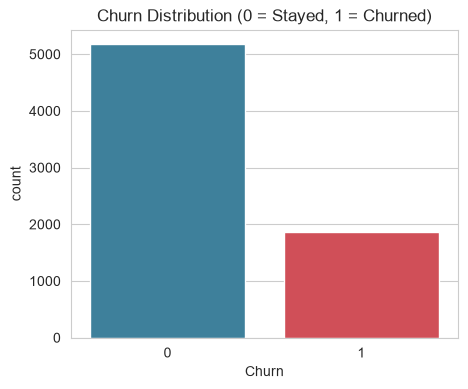

In [13]:
churn_rate = df_clean['Churn'].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

plt.figure(figsize=(5,4))
sns.countplot(data=df_clean, x='Churn', palette=['#2E86AB','#E63946'])
plt.title('Churn Distribution (0 = Stayed, 1 = Churned)')
plt.show()


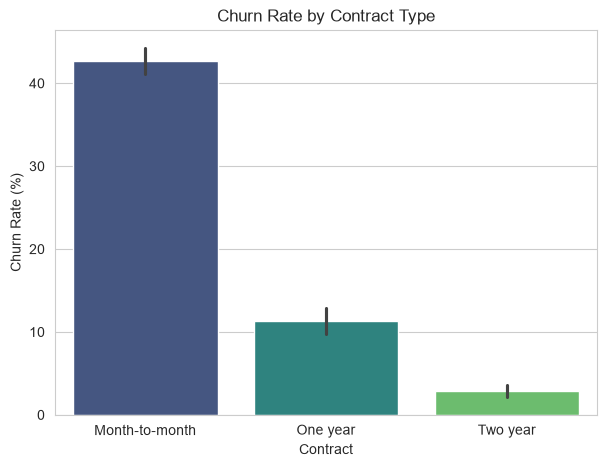

In [14]:
# Churn rate by Contract type
plt.figure(figsize=(7,5))
sns.barplot(data=df_clean, x='Contract', y='Churn', estimator=lambda x: sum(x)/len(x)*100, palette='viridis')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Contract Type')
plt.show()

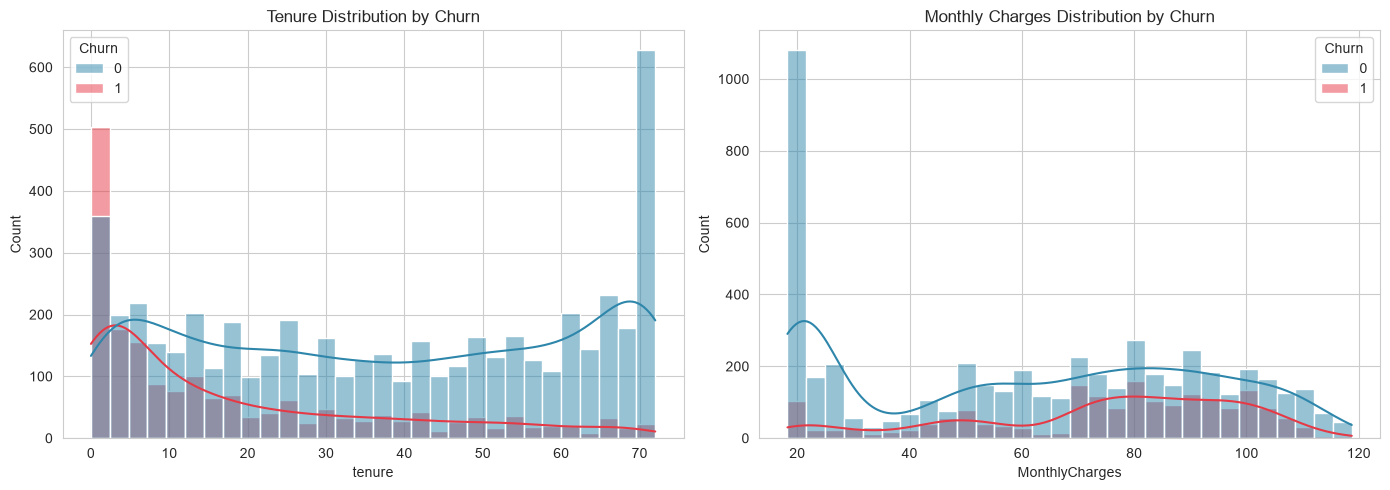

In [15]:
# Tenure and MonthlyCharges distribution by churn
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(data=df_clean, x='tenure', hue='Churn', bins=30, kde=True, ax=axes[0], palette=['#2E86AB','#E63946'])
axes[0].set_title('Tenure Distribution by Churn')

sns.histplot(data=df_clean, x='MonthlyCharges', hue='Churn', bins=30, kde=True, ax=axes[1], palette=['#2E86AB','#E63946'])
axes[1].set_title('Monthly Charges Distribution by Churn')
plt.tight_layout()
plt.show()

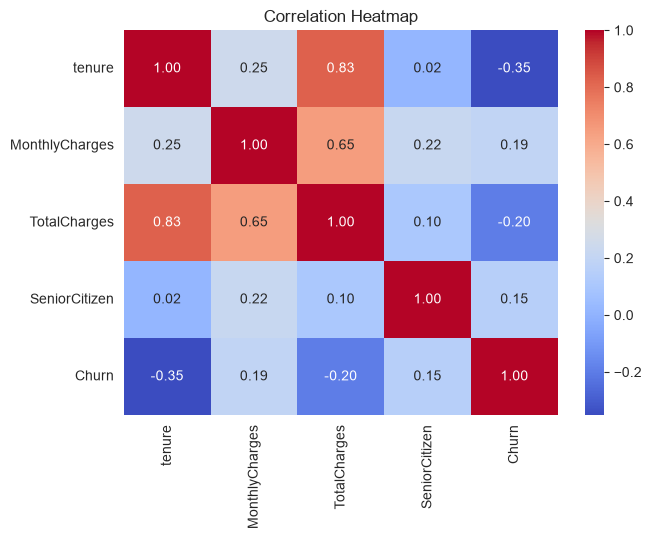

In [16]:
# Correlation heatmap of numeric features
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']
plt.figure(figsize=(7,5))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**EDA Insights to note in your report:**
- Churn rate is imbalanced (~26% churn vs ~74% stay) → must use SMOTE / balanced metrics later.
- Month-to-month contract customers churn far more than 1-year/2-year contract customers.
- Low-tenure customers churn more — loyalty builds over time.
- Higher monthly charges correlate with higher churn.


## 5. Feature Engineering

We prepare two versions of the data:
- **`df_encoded`** — fully one-hot encoded, used for supervised classification.
- **A numeric subset** — used for unsupervised clustering (Section 6), since clustering works best on
  scaled numeric/behavioral features rather than every one-hot dummy column.

In [17]:
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
print("\nEncoded dataset shape:", df_encoded.shape)
df_encoded.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Encoded dataset shape: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


---
## 6. Unsupervised Learning — Customer Segmentation

**Goal:** Group customers into behaviorally meaningful segments WITHOUT using the `Churn` label.
This answers "who are our customers?" independent of who churns.

**Steps:** scale features → find optimal K (Elbow + Silhouette) → run K-Means → validate with
Hierarchical Clustering → visualize with PCA → profile each segment.

In [18]:
# Select behavioral features for clustering (exclude target Churn — clustering is unsupervised!)
cluster_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_cluster = df_clean[cluster_features].copy()

# Scale features - required for distance-based algorithms like K-Means
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print("Features used for clustering:", cluster_features)
print("Scaled data shape:", X_cluster_scaled.shape)

Features used for clustering: ['tenure', 'MonthlyCharges', 'TotalCharges']
Scaled data shape: (7043, 3)


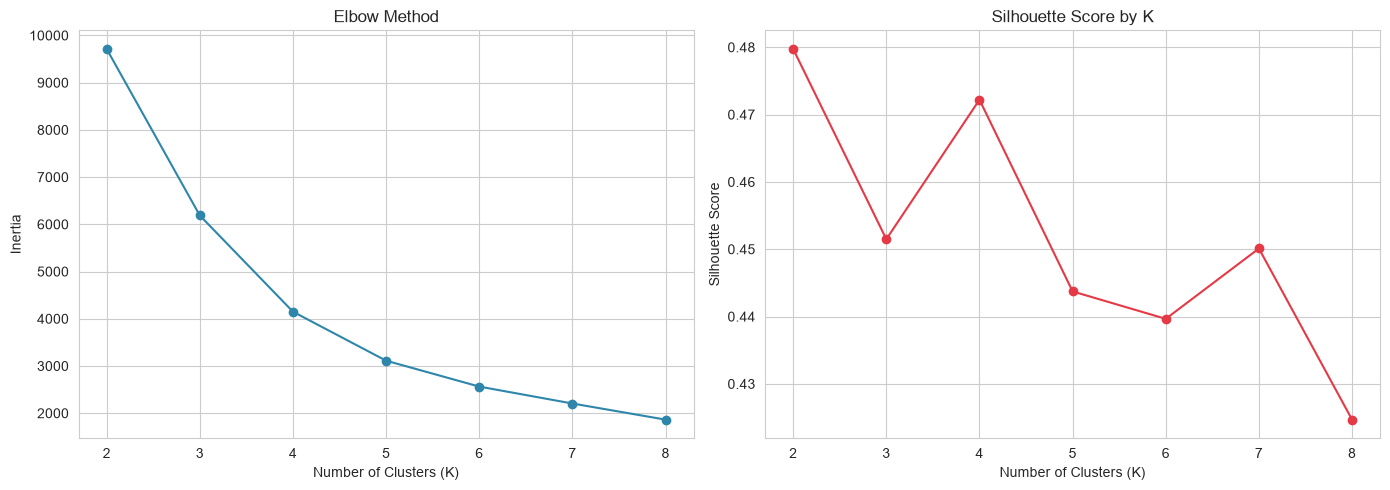

K=2: Silhouette Score = 0.4797
K=3: Silhouette Score = 0.4515
K=4: Silhouette Score = 0.4722
K=5: Silhouette Score = 0.4437
K=6: Silhouette Score = 0.4397
K=7: Silhouette Score = 0.4501
K=8: Silhouette Score = 0.4247


In [19]:
# Elbow Method - find optimal number of clusters
inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(K_range, inertias, marker='o', color='#2E86AB')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouette_scores, marker='o', color='#E63946')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
plt.tight_layout()
plt.show()

for k, s in zip(K_range, silhouette_scores):
    print(f"K={k}: Silhouette Score = {s:.4f}")

**Decision point:** Pick the K where the elbow bends AND silhouette score is high (usually K=3 or K=4
for this dataset). Update `OPTIMAL_K` below based on YOUR chart output.

In [20]:
OPTIMAL_K = 4  # <-- update this based on your elbow/silhouette results

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(f"K-Means with K={OPTIMAL_K} complete.")
print(df_clean['Cluster'].value_counts().sort_index())

K-Means with K=4 complete.
Cluster
0    1703
1    1904
2    2276
3    1160
Name: count, dtype: int64


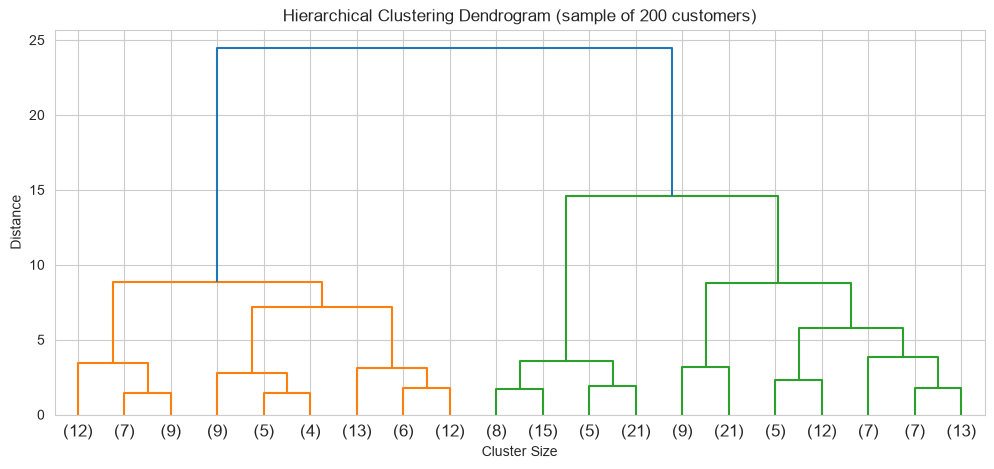

Agglomerative clustering silhouette score: 0.38209921158275545
K-Means silhouette score:             0.4722013989143837


In [21]:
# Validate with Hierarchical Clustering on a sample (full dataset is slow for dendrograms)
from scipy.cluster.hierarchy import dendrogram, linkage

sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_cluster_scaled), 200, replace=False)
sample_data = X_cluster_scaled[sample_idx]

linked = linkage(sample_data, method='ward')
plt.figure(figsize=(12,5))
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title('Hierarchical Clustering Dendrogram (sample of 200 customers)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()

# Fit Agglomerative Clustering on full scaled data with same K for comparison
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K)
agg_labels = agg.fit_predict(X_cluster_scaled)
print("Agglomerative clustering silhouette score:", silhouette_score(X_cluster_scaled, agg_labels))
print("K-Means silhouette score:            ", silhouette_score(X_cluster_scaled, df_clean['Cluster']))

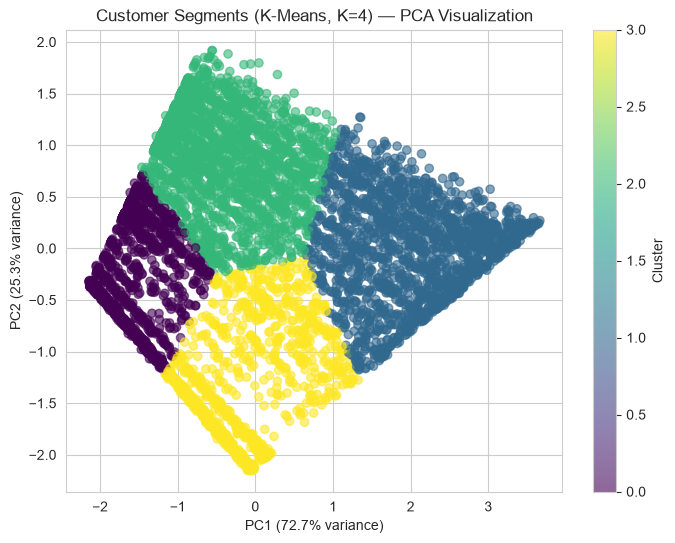

In [22]:
# Visualize clusters in 2D using PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(pca_coords[:,0], pca_coords[:,1], c=df_clean['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'Customer Segments (K-Means, K={OPTIMAL_K}) — PCA Visualization')
plt.colorbar(scatter, label='Cluster')
plt.show()


In [23]:
# Profile each cluster - THIS is what makes segmentation useful for the business
cluster_profile = df_clean.groupby('Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2)
cluster_profile['Count'] = df_clean['Cluster'].value_counts().sort_index()
cluster_profile['Churn_Rate_%'] = (df_clean.groupby('Cluster')['Churn'].mean() * 100).round(2)
cluster_profile

,tenure,MonthlyCharges,TotalCharges,Count,Churn_Rate_%
Cluster,,,,,
0,10.21,31.78,302.15,1703,24.66
1,59.53,93.31,5548.65,1904,15.39
2,15.42,80.78,1251.17,2276,48.24
3,53.57,34.91,1835.62,1160,5.00


**Action item for Member 1:** Name each cluster based on the profile table above, e.g.:
- Cluster 0: "New high-spend at-risk customers" (low tenure, high charges, high churn)
- Cluster 1: "Loyal long-term low-spenders" (high tenure, low charges, low churn)
- etc. — write these names down, you'll need them in Section 9 (Integration).


---
## 7. Supervised Learning — Churn Prediction

**Goal:** Predict `Churn` (1 = will leave, 0 = will stay) using the fully encoded feature set.

**Steps:** train/test split → handle class imbalance with SMOTE → train 3 models
(Logistic Regression, Random Forest, XGBoost) → tune the best one with GridSearchCV.


In [24]:
# Prepare X and y (drop the Cluster column here - it's from Section 6, keep classification independent)
X = df_encoded.drop(columns=['Churn'])
if 'Cluster' in X.columns:
    X = X.drop(columns=['Cluster'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Churn rate in train:", y_train.mean().round(3), " | in test:", y_test.mean().round(3))

Train shape: (5634, 30)  Test shape: (1409, 30)
Churn rate in train: 0.265  | in test: 0.265


In [25]:
# Handle class imbalance - apply SMOTE ONLY on the training set (never on test set!)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE:  {0: 4139, 1: 4139}


In [26]:
# Baseline: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_res, y_train_res)
y_pred_lr = log_reg.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1035
           1       0.52      0.63      0.57       374

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.75      0.76      1409



In [27]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1035
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409



In [28]:
# XGBoost
xgb = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.57      0.58      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.77      0.77      1409



In [29]:
# Hyperparameter tuning on the best-performing model so far (example: Random Forest)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid, cv=3, scoring='f1', n_jobs=-1
)
grid_rf.fit(X_train_res, y_train_res)

print("Best params:", grid_rf.best_params_)
best_model = grid_rf.best_estimator_
y_pred_best = best_model.predict(X_test)
print("\n=== Tuned Random Forest ===")
print(classification_report(y_test, y_pred_best))

Best params: {'max_depth': 12, 'min_samples_split': 2, 'n_estimators': 100}

=== Tuned Random Forest ===
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.56      0.68      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



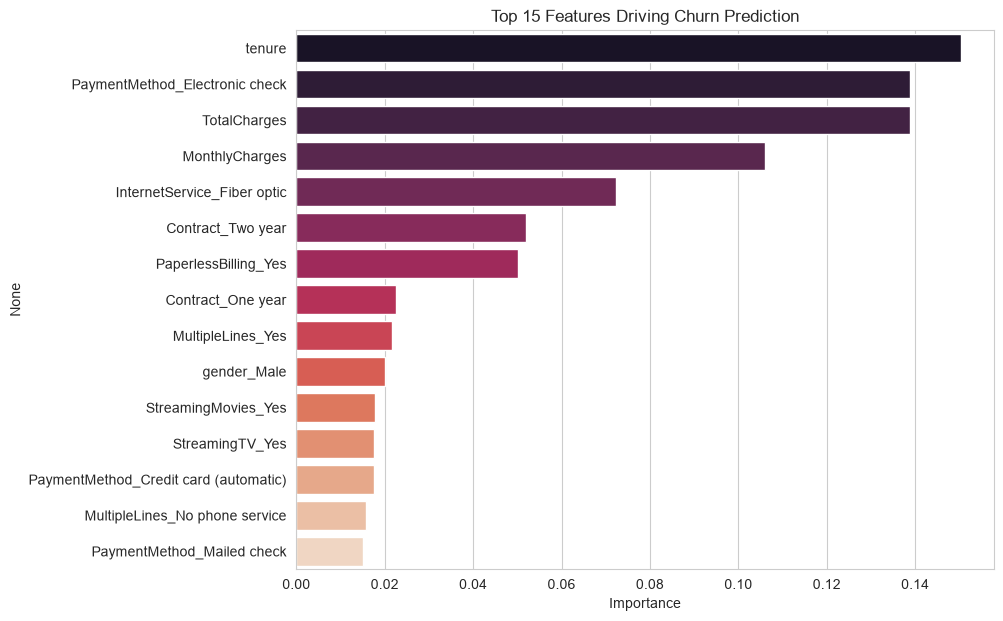

In [30]:
# Feature importance from the best model - which factors drive churn most?
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9,7))
sns.barplot(x=importances.values, y=importances.index, palette='rocket')
plt.title('Top 15 Features Driving Churn Prediction')
plt.xlabel('Importance')
plt.show()

---
## 8. Model Evaluation

We compare all models using metrics appropriate for imbalanced classification —
**accuracy alone is misleading** here (a model that always predicts "no churn" would score ~74%).
We focus on **Recall** (catching actual churners) and **ROC-AUC**.


In [31]:
models_preds = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'Tuned Random Forest': y_pred_best
}

results = []
for name, preds in models_preds.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results).round(3).sort_values('F1-Score', ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1-Score
3,Tuned Random Forest,0.775,0.563,0.676,0.615
2,XGBoost,0.774,0.574,0.583,0.578
1,Random Forest,0.771,0.567,0.588,0.577
0,Logistic Regression,0.750,0.524,0.631,0.573


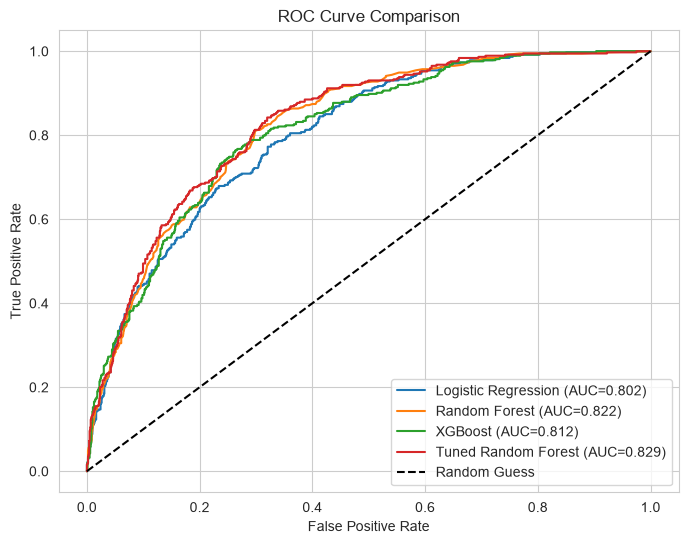

In [32]:
# ROC-AUC comparison (uses predicted probabilities, not hard labels)
plt.figure(figsize=(8,6))

for name, model in [('Logistic Regression', log_reg), ('Random Forest', rf),
                     ('XGBoost', xgb), ('Tuned Random Forest', best_model)]:
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


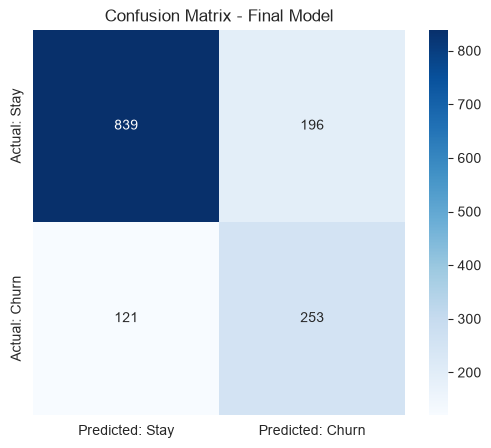

In [33]:
# Confusion matrix for the final chosen model
FINAL_MODEL = best_model
FINAL_PREDS = y_pred_best

cm = confusion_matrix(y_test, FINAL_PREDS)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stay','Predicted: Churn'],
            yticklabels=['Actual: Stay','Actual: Churn'])
plt.title('Confusion Matrix - Final Model')
plt.show()

---
## 9. Integration — Combining Segments with Churn Insights

**Goal:** This is what makes the project "unique" rather than two disconnected mini-projects —
we check whether specific customer segments (from Section 6) have disproportionately high churn,
and generate churn probability scores for every customer.

In [34]:
# Generate churn probability for EVERY customer (not just test set) using the final model
X_full = df_encoded.drop(columns=['Churn'])
if 'Cluster' in X_full.columns:
    X_full = X_full.drop(columns=['Cluster'])

df_clean['Churn_Probability'] = FINAL_MODEL.predict_proba(X_full)[:,1].round(3)

# Cross-tabulate: churn rate AND avg churn probability by cluster
integration_table = df_clean.groupby('Cluster').agg(
    Customer_Count=('Churn','count'),
    Actual_Churn_Rate_pct=('Churn', lambda x: round(x.mean()*100,2)),
    Avg_Predicted_Churn_Prob=('Churn_Probability', lambda x: round(x.mean(),3)),
    Avg_Tenure=('tenure','mean'),
    Avg_MonthlyCharges=('MonthlyCharges','mean')
).round(2)

integration_table


,Customer_Count,Actual_Churn_Rate_pct,Avg_Predicted_Churn_Prob,Avg_Tenure,Avg_MonthlyCharges
Cluster,,,,,
0,1703,24.66,0.31,10.21,31.78
1,1904,15.39,0.23,59.53,93.31
2,2276,48.24,0.56,15.42,80.78
3,1160,5.00,0.07,53.57,34.91


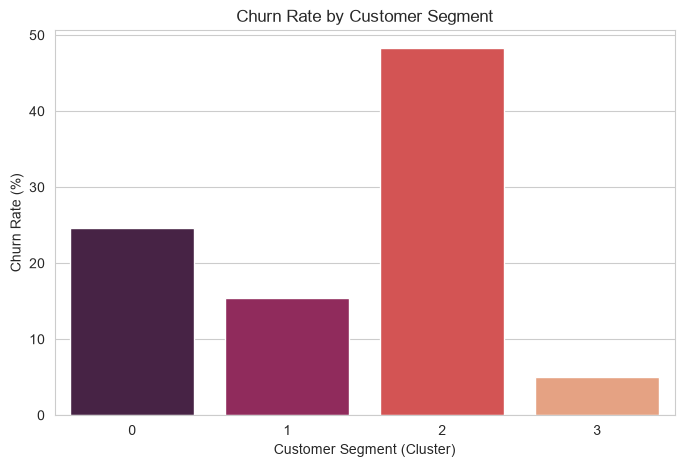

In [35]:
# Visualize churn risk by segment
plt.figure(figsize=(8,5))
sns.barplot(x=integration_table.index, y=integration_table['Actual_Churn_Rate_pct'], palette='rocket')
plt.xlabel('Customer Segment (Cluster)')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Customer Segment')
plt.show()

In [36]:
# Flag high-risk customers: top segment(s) with highest churn rate
high_risk_cluster = integration_table['Actual_Churn_Rate_pct'].idxmax()
high_risk_customers = df_clean[df_clean['Cluster'] == high_risk_cluster].sort_values(
    'Churn_Probability', ascending=False
)

print(f"Highest-risk segment: Cluster {high_risk_cluster}")
print(f"Number of customers in this segment: {len(high_risk_customers)}")
high_risk_customers[['tenure','MonthlyCharges','TotalCharges','Churn_Probability']].head(10)

Highest-risk segment: Cluster 2
Number of customers in this segment: 2276


,tenure,MonthlyCharges,TotalCharges,Churn_Probability
1704,1,99.75,99.75,0.974
6240,1,93.30,93.30,0.971
6482,1,101.45,101.45,0.971
2745,1,86.05,86.05,0.968
915,1,73.55,73.55,0.966
2821,1,74.40,74.40,0.965
4453,10,98.50,1037.75,0.964
1976,1,93.55,93.55,0.964
5714,4,97.95,384.50,0.962
4800,1,94.00,94.00,0.962


## 10. Business Recommendations

_Fill this in as a team based on YOUR actual output from Sections 6-9. Example structure:_

1. **Segment [X] ("New high-spend at-risk")** shows a churn rate of **__%**, far above the overall
   average of **__%**. Recommend: targeted onboarding offers / loyalty discounts in the first 90 days.
2. **Contract type** was the strongest predictor of churn (see feature importance chart) — recommend
   incentivizing month-to-month customers to switch to annual contracts.
3. **Top 15% highest churn-probability customers** (from Section 9) should be prioritized for a
   retention campaign — estimated at **__ customers**.
4. **Segment [Y] ("Loyal low-spenders")** has minimal churn risk — safe to deprioritize for retention
   spend, focus resources elsewhere.


## 11. Save Models & Outputs

Save trained models and the final scored dataset — needed for the Streamlit dashboard and for
reproducibility (don't retrain every time you open the notebook).

In [37]:
import os
import json
os.makedirs('../reports', exist_ok=True)

# Save models
joblib.dump(FINAL_MODEL, '../reports/churn_model.pkl')
joblib.dump(kmeans, '../reports/kmeans_model.pkl')
joblib.dump(scaler, '../reports/scaler.pkl')

# Save the final scored dataset (with cluster + churn probability) for the dashboard
df_clean.to_csv('../reports/scored_customers.csv', index=False)

# Save the exact list + order of encoded feature columns the model expects.
# The Streamlit app uses this to correctly one-hot-encode new raw user input
# to match what the model was trained on (via reindex).
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, '../reports/feature_columns.pkl')

# Save the raw category options for each categorical column (used to build
# dropdowns in the app) plus numeric min/max/mean (used for sliders).
raw_categorical_options = {
    col: sorted(df_clean[col].dropna().unique().tolist())
    for col in categorical_cols if col != 'Churn'
}
numeric_ranges = {
    col: {
        'min': float(df_clean[col].min()),
        'max': float(df_clean[col].max()),
        'mean': float(df_clean[col].mean())
    }
    for col in ['tenure', 'MonthlyCharges', 'TotalCharges']
}
with open('../reports/input_schema.json', 'w') as f:
    json.dump({'categorical_options': raw_categorical_options, 'numeric_ranges': numeric_ranges}, f, indent=2)

# Save model comparison metrics (for the app's Model Performance page)
results_df.to_csv('../reports/model_metrics.csv', index=False)

# Save feature importance (for the app's Model Performance page)
importances.to_csv('../reports/feature_importance.csv', header=['importance'])

# Save cluster profile summary
cluster_profile.to_csv('../reports/cluster_profile.csv')

print("All models and artifacts saved to /reports:")
for f in sorted(os.listdir('../reports')):
    print(" -", f)

All models and artifacts saved to /reports:
 - churn_model.pkl
 - cluster_profile.csv
 - feature_columns.pkl
 - feature_importance.csv
 - input_schema.json
 - kmeans_model.pkl
 - model_metrics.csv
 - scaler.pkl
 - scored_customers.csv


In [38]:
import os
print(os.getcwd())

C:\Users\winlo\Customer_segmentation_churn_prediction
